# Sales Trends

Historical sales-trend analysis. Pick the **city** in the first code cell
(`CITY = get_city("livingston")` or `"millburn"`), which loads
`data/<city>/merged.csv`.

Pipeline: **load & clean** → **filter to a segment** → **plot trends** (median price, volume, $/sqft) → monthly/seasonal tables.

Edit the `FILTERS` cell to slice by year range, beds, property class, or **`zip`**
(e.g. `"07078"` Short Hills). ZIP comes from the geocode cache (the merged data
has no ZIP column), so run `src/geocode.py <city>` first; the load cell prints
the ZIPs available.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))
from config import get_city

# --- choose the city here: "livingston" or "millburn" ---
CITY = get_city("millburn")

pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

DATA = CITY.data
assert DATA.exists(), f"missing {DATA} — run the merge step first"
print("city:", CITY.label)

city: Millburn Township (07041)


## 1. Load & clean

Parses dates and numerics, then flags rows that should be excluded from price trends:

- **non-arms-length / nominal sales** — price < $1,000 (the data has thousands of $0–$10 transfers: estate, LLC, intra-family, deed corrections).
- **unparseable sale dates**.

`df` = everything; `clean` = arms-length residential-usable rows. `$/sqft` additionally needs `Sq Ft > 0`.

In [2]:
raw = pd.read_csv(DATA, dtype=str)

df = raw.copy()
df["sale_date"] = pd.to_datetime(df["Sale Date"], format="%m/%d/%Y", errors="coerce")
df["price"]   = pd.to_numeric(df["Sale Price"], errors="coerce")
df["sqft"]    = pd.to_numeric(df["Sq Ft"], errors="coerce")
df["beds"]    = pd.to_numeric(df["Beds"], errors="coerce")
df["year"]    = df["sale_date"].dt.year
df["ppsf"]    = df["price"] / df["sqft"].where(df["sqft"] > 0)

# attach ZIP from the geocode cache (derived from the matched locality). The
# merged data has no ZIP column, so this is how we get per-ZIP slicing.
df["addr"] = df["Property Address"].str.strip()
if CITY.geocode_cache.exists():
    gc = pd.read_csv(CITY.geocode_cache, dtype={"address": str, "zip": str})
    df = df.merge(gc[["address", "zip"]], left_on="addr", right_on="address", how="left")
else:
    df["zip"] = pd.NA
    print("note: no geocode cache — run src/geocode.py for ZIP filtering")

MIN_PRICE = 1_000
df["arms_length"] = df["price"] >= MIN_PRICE

clean = df[df["sale_date"].notna() & df["arms_length"]].copy()

print(f"raw rows:        {len(df):,}")
print(f"dropped (no date): {df['sale_date'].isna().sum():,}")
print(f"dropped (price < ${MIN_PRICE:,}): {(~df['arms_length']).sum():,}")
print(f"clean rows:      {len(clean):,}")
print(f"date range:      {clean['sale_date'].min():%Y-%m-%d} → {clean['sale_date'].max():%Y-%m-%d}")
print(f"ZIPs present:    {sorted(clean['zip'].dropna().unique())}")

raw rows:        7,506
dropped (no date): 0
dropped (price < $1,000): 0
clean rows:      7,506
date range:      2000-03-12 → 2026-06-05
ZIPs present:    ['07041', '07078']


## 2. Filters

Set the segment to analyze. `None` means "no filter on that field". Re-run from here down after changing.

In [3]:
FILTERS = dict(
    property_class=CITY.residential_class,  # per-city: Livingston "Residential", Millburn "SinglFam"; set None for all
    year_min=2000,                          # or None
    year_max=None,
    beds=None,                              # exact bed count, e.g. 3, or None
    zip="07078",                               # e.g. "07078" (Short Hills); None = all ZIPs
)

def apply_filters(data, property_class=None, year_min=None, year_max=None, beds=None, zip=None):
    d = data
    if property_class is not None:
        d = d[d["Property Class"] == property_class]
    if year_min is not None:
        d = d[d["year"] >= year_min]
    if year_max is not None:
        d = d[d["year"] <= year_max]
    if beds is not None:
        d = d[d["beds"] == beds]
    if zip is not None:
        d = d[d["zip"] == str(zip)]
    return d

seg = apply_filters(clean, **FILTERS)
_segdesc = ", ".join(f"{k}={v}" for k, v in FILTERS.items() if v is not None) or "all sales"
label = f"{CITY.name} — {_segdesc}"   # used in plot titles / export filename
print(f"segment: {label}")
print(f"rows in segment: {len(seg):,}")
if seg.empty:
    classes = sorted(clean["Property Class"].dropna().unique())
    zips = sorted(clean["zip"].dropna().unique())
    raise ValueError(
        f"Empty segment — no rows match {FILTERS}. "
        f"For {CITY.name}: Property Class values {classes}; ZIPs {zips}. "
        "Adjust the FILTERS cell (e.g. property_class=None or a valid zip)."
    )

segment: millburn — property_class=SinglFam, year_min=2000, zip=07078
rows in segment: 3,381


## 3. Yearly trend table

Median price is the headline (robust to the occasional multi-million-dollar outlier); mean shown alongside. `ppsf` excludes zero-sqft rows.

In [4]:
yearly = seg.groupby("year").agg(
    sales=("price", "size"),
    median_price=("price", "median"),
    mean_price=("price", "mean"),
    p25_ppsf=("ppsf", lambda s: s.quantile(0.25)),
    median_ppsf=("ppsf", "median"),
    p75_ppsf=("ppsf", lambda s: s.quantile(0.75)),
).round(0)
yearly

,sales,median_price,mean_price,p25_ppsf,median_ppsf,p75_ppsf
year,,,,,,
2008,82,"1,087,500","1,285,507",310,354,367
2009,143,"1,165,000","1,452,341",280,333,365
2010,169,"1,205,000","1,388,549",318,351,391
2011,150,"1,232,500","1,365,954",294,329,388
2012,179,"1,210,000","1,391,556",303,322,358
2013,214,"1,422,500","1,574,583",320,352,393
2014,212,"1,377,500","1,587,069",344,365,426
2015,209,"1,387,500","1,609,228",330,384,418
2016,215,"1,450,000","1,620,115",336,371,422


## 4. Price trend over time

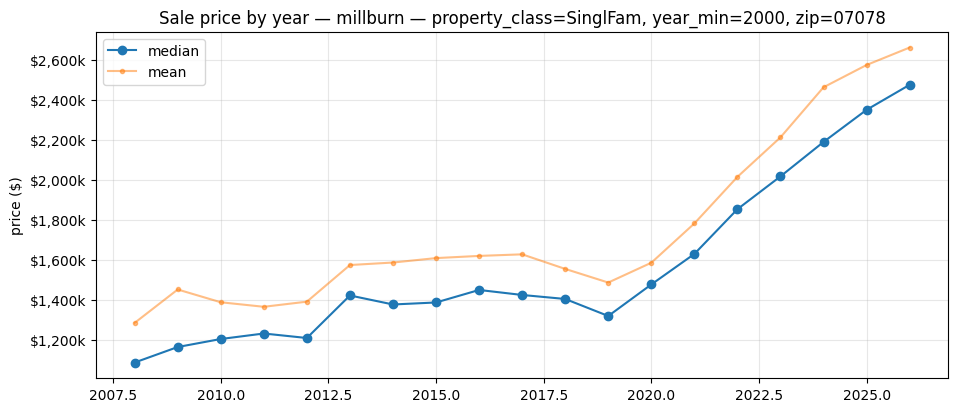

In [5]:
fig, ax = plt.subplots()
ax.plot(yearly.index, yearly["median_price"], marker="o", label="median")
ax.plot(yearly.index, yearly["mean_price"], marker=".", alpha=0.5, label="mean")
ax.set_title(f"Sale price by year — {label}")
ax.set_ylabel("price ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:,.0f}k")
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 5. Sales volume by year

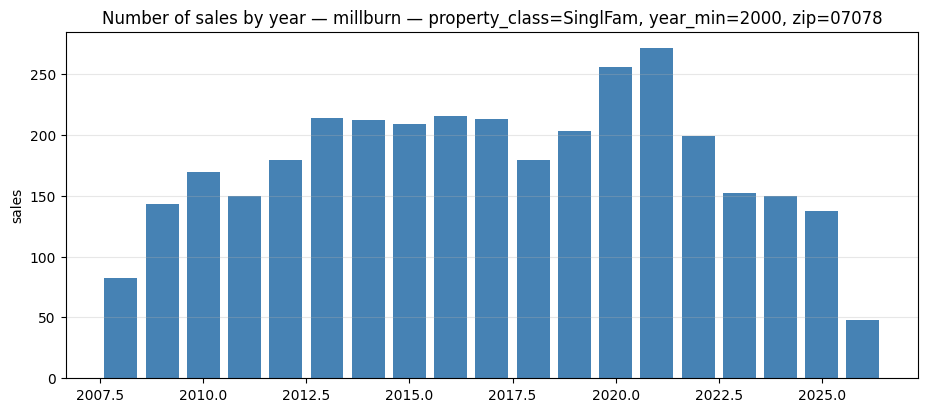

In [6]:
fig, ax = plt.subplots()
ax.bar(yearly.index, yearly["sales"], color="steelblue")
ax.set_title(f"Number of sales by year — {label}")
ax.set_ylabel("sales")
ax.grid(alpha=0.3, axis="y")
plt.show()

## 6. Price per square foot by year

Median $/sqft with the **25th and 75th percentiles** (the shaded band = the middle half of the market: 25th = lower end, 75th = upper end / larger or renovated homes).

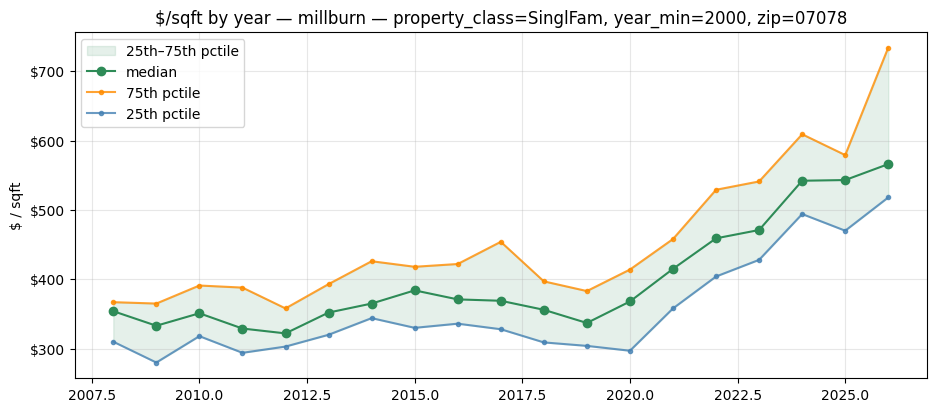

In [7]:
ppsf = yearly[["p25_ppsf", "median_ppsf", "p75_ppsf"]].dropna()
fig, ax = plt.subplots()
ax.fill_between(ppsf.index, ppsf["p25_ppsf"], ppsf["p75_ppsf"],
                color="seagreen", alpha=0.12, label="25th–75th pctile")
ax.plot(ppsf.index, ppsf["median_ppsf"], marker="o", color="seagreen", label="median")
ax.plot(ppsf.index, ppsf["p75_ppsf"], marker=".", color="darkorange",
        alpha=0.8, label="75th pctile")
ax.plot(ppsf.index, ppsf["p25_ppsf"], marker=".", color="steelblue",
        alpha=0.8, label="25th pctile")
ax.set_title(f"$/sqft by year — {label}")
ax.set_ylabel("$ / sqft")
ax.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 7. Monthly stats

Finer-grained than yearly. Views below: a year-month **time series**, **seasonality** (by calendar month), **year-over-year** change, and **% vs. prior year-end** for the last 15 years.

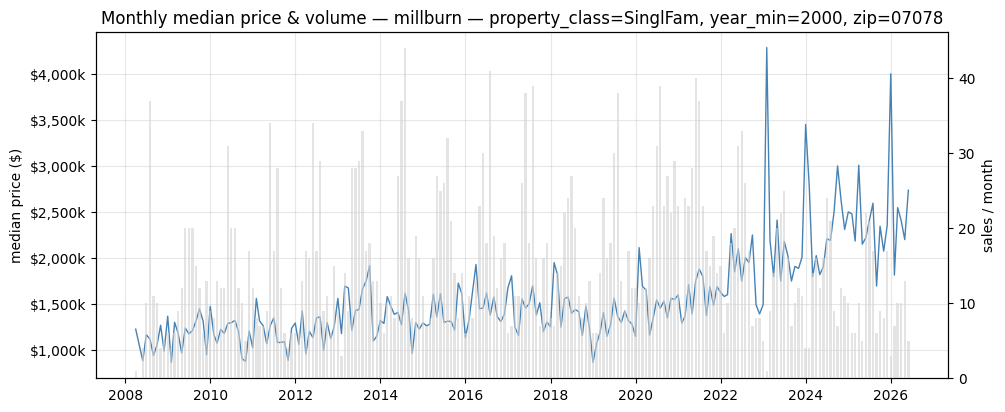

,sales,median_price,median_ppsf
ym,,,
2025-07,21,"2,408,750",583
2025-08,17,"2,595,000",556
2025-09,6,"1,695,750",397
2025-10,9,"2,345,000",592
2025-11,8,"2,074,500",468
2025-12,17,"2,350,000",446
2026-01,3,"4,000,000",NaN
2026-02,7,"1,815,000",613
2026-03,10,"2,547,500",644


In [8]:
monthly = seg.copy()
monthly["ym"] = monthly["sale_date"].dt.to_period("M")
monthly = monthly.groupby("ym").agg(
    sales=("price", "size"),
    median_price=("price", "median"),
    median_ppsf=("ppsf", "median"),
).round(0)

# plot monthly median price + volume (volume on a twin axis)
idx = monthly.index.to_timestamp()
fig, ax = plt.subplots()
ax.plot(idx, monthly["median_price"], color="steelblue", lw=1, label="median price")
ax.set_ylabel("median price ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:,.0f}k")
ax.set_title(f"Monthly median price & volume — {label}")
ax2 = ax.twinx()
ax2.bar(idx, monthly["sales"], width=20, color="lightgray", alpha=0.6, label="sales")
ax2.set_ylabel("sales / month")
ax.grid(alpha=0.3)
plt.show()

monthly.tail(12)

### Seasonality

Metrics aggregated by calendar month across all years in the segment — which months sell most / priciest.

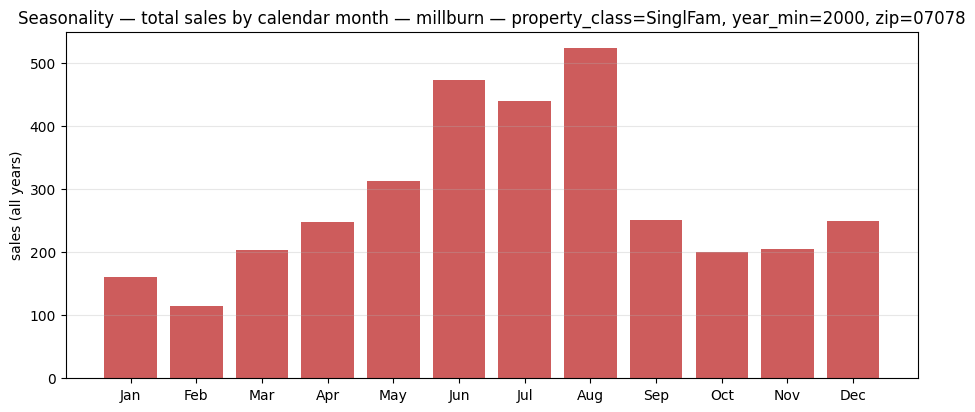

,sales,median_price,median_ppsf
Jan,161,"1,426,500",367
Feb,115,"1,500,000",372
Mar,203,"1,575,000",372
Apr,248,"1,620,000",390
May,313,"1,455,000",385
Jun,472,"1,524,500",392
Jul,440,"1,565,000",405
Aug,523,"1,500,000",353
Sep,251,"1,420,000",403
Oct,200,"1,462,500",385


In [9]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
season = seg.assign(month=seg["sale_date"].dt.month).groupby("month").agg(
    sales=("price", "size"),
    median_price=("price", "median"),
    median_ppsf=("ppsf", "median"),
).round(0)
season.index = [MONTHS[m - 1] for m in season.index]

fig, ax = plt.subplots()
ax.bar(season.index, season["sales"], color="indianred")
ax.set_title(f"Seasonality — total sales by calendar month — {label}")
ax.set_ylabel("sales (all years)")
ax.grid(alpha=0.3, axis="y")
plt.show()

season

### Year-over-year price change

Each month's median price vs. the **same month one year earlier** (cancels seasonality). Monthly YoY is noisy at ~30 sales/month, so a **12-month rolling-median YoY** is shown alongside as the steadier signal.

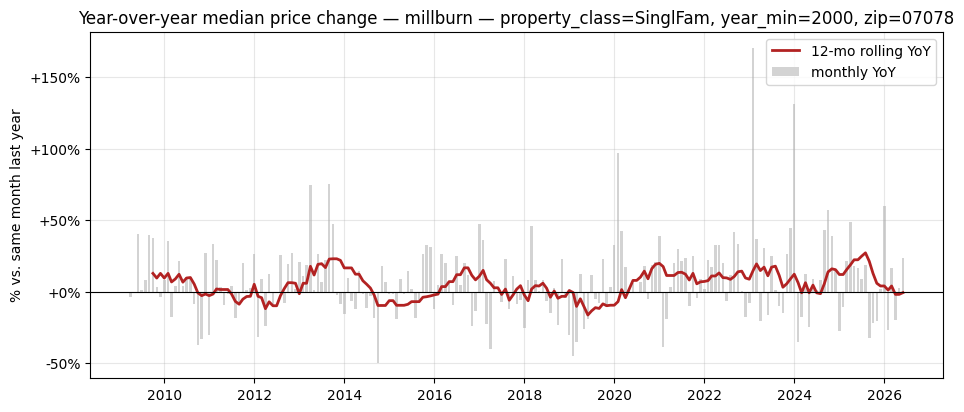

,sales,median_price,yoy_%,yoy_smooth_%
2025-07,21,"2,408,750",9,25
2025-08,17,"2,595,000",18,27
2025-09,6,"1,695,750",-32,21
2025-10,9,"2,345,000",-22,13
2025-11,8,"2,074,500",-21,6
2025-12,17,"2,350,000",2,4
2026-01,3,"4,000,000",60,4
2026-02,7,"1,815,000",-27,1
2026-03,10,"2,547,500",17,4
2026-04,10,"2,402,500",-20,-2


In [10]:
# reindex to a continuous monthly range so shift(12) lands on exactly the same
# month a year earlier even if some month had no sales.
yoy = monthly.reindex(pd.period_range(monthly.index.min(), monthly.index.max(), freq="M"))
yoy["yoy_%"] = (yoy["median_price"] / yoy["median_price"].shift(12) - 1) * 100
yoy["smooth"] = yoy["median_price"].rolling(12, min_periods=6).median()
yoy["yoy_smooth_%"] = (yoy["smooth"] / yoy["smooth"].shift(12) - 1) * 100

t = yoy.index.to_timestamp()
fig, ax = plt.subplots()
ax.bar(t, yoy["yoy_%"], width=20, color="lightgray", label="monthly YoY")
ax.plot(t, yoy["yoy_smooth_%"], color="firebrick", lw=2, label="12-mo rolling YoY")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Year-over-year median price change — {label}")
ax.set_ylabel("% vs. same month last year")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
ax.grid(alpha=0.3); ax.legend()
plt.show()

yoy[["sales", "median_price", "yoy_%", "yoy_smooth_%"]].tail(12).round(1)

### Monthly % change vs. prior year-end (last 20 years)

Each month's median price as a **% change from the prior calendar year's median**
(the basis resets each January). E.g. a `+27` in 2025-Mar means March 2025's
median ran 27% above the 2024 full-year median. Rows = year, columns = month, for
the **last 20 years** (earlier years have too few sales/month and swing wildly).
The `Avg` row averages each month down the years. Respects the property-class /
beds `FILTERS` but **not** the year range. The current year is partial.

In [11]:
# Basis = prior calendar year's median. Use class/beds/zip filters but ignore the
# year range. Last 20 years only — earlier years have too few sales/month, so
# their monthly medians swing wildly and would distort the table & Avg.
base = apply_filters(clean, property_class=FILTERS["property_class"],
                     beds=FILTERS["beds"], zip=FILTERS["zip"])
base = base.assign(month=base["sale_date"].dt.month)

yearly_med = base.groupby("year")["price"].median()
mm = base.groupby(["year", "month"])["price"].median().rename("median").reset_index()
mm["pct"] = (mm["median"] / mm["year"].sub(1).map(yearly_med) - 1) * 100

last20 = sorted(base["year"].dropna().unique())[-20:]
pct_table = (mm[mm["year"].isin(last20)]
             .pivot(index="year", columns="month", values="pct")
             .reindex(columns=range(1, 13)))
pct_table.columns = MONTHS
pct_table.index = pct_table.index.astype(int)

# append a column-average row (mean of each month down the years, skipping NaNs)
pct_table.loc["Avg"] = pct_table.mean(axis=0)

pct_table.style.format("{:+.1f}%", na_rep="—").background_gradient(
    cmap="RdYlGn", axis=None, vmin=-20, vmax=20)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2008,—,—,—,—,—,—,—,—,—,—,—,—
2009,+25.8%,-20.4%,+19.8%,+8.4%,-10.9%,+14.0%,+8.3%,+11.4%,+20.9%,+33.1%,+20.9%,-12.6%
2010,+26.6%,+0.4%,-7.7%,+5.3%,+1.3%,+10.6%,+11.5%,+13.6%,+3.1%,-22.1%,-24.6%,+3.6%
2011,-15.0%,+29.5%,+9.1%,+5.0%,-11.2%,+5.3%,+12.0%,-10.2%,-10.0%,-9.4%,-26.3%,+2.7%
2012,+5.0%,-13.8%,+15.7%,-22.1%,-2.3%,-7.9%,+9.5%,+10.4%,-18.9%,+5.5%,-8.7%,+2.2%
2013,+29.0%,-2.5%,+40.1%,+38.4%,+0.4%,+18.3%,+19.0%,+37.6%,+44.6%,+58.5%,-9.1%,-5.0%
2014,-7.2%,-9.3%,+11.2%,+3.7%,-2.4%,-0.9%,-10.4%,+13.7%,+0.2%,-32.2%,-8.6%,-13.7%
2015,-6.0%,-8.2%,-7.1%,+16.7%,-1.3%,+17.1%,-5.6%,-4.5%,-4.9%,-11.6%,+25.4%,+17.2%
2016,-18.0%,-4.5%,+16.7%,+39.1%,+4.5%,+5.0%,+16.8%,-0.5%,+13.5%,-1.8%,-5.6%,+0.2%


### Seasonal % change vs. prior year-end (last 20 years)

Same basis as above (prior calendar year's median), but pooled into 3-month
seasons: **Dec–Feb, Mar–May, Jun–Aug, Sep–Nov**. Each season's median uses all
sales in its three months, then compared to the prior year's median. Winter
(Dec–Feb) is labeled by the year it ends in, so its December comes from the prior
calendar year. Pooling ~3 months of sales makes each cell steadier than the
single-month table. `Avg` row averages each season down the years.

In [12]:
SEASON = {12: "Dec-Feb", 1: "Dec-Feb", 2: "Dec-Feb",
          3: "Mar-May", 4: "Mar-May", 5: "Mar-May",
          6: "Jun-Aug", 7: "Jun-Aug", 8: "Jun-Aug",
          9: "Sep-Nov", 10: "Sep-Nov", 11: "Sep-Nov"}
SEASON_ORDER = ["Dec-Feb", "Mar-May", "Jun-Aug", "Sep-Nov"]

s = base.copy()
s["season"] = s["month"].map(SEASON)
# label winter by the year it ends in: December rolls into next year's Dec-Feb
s["season_year"] = s["year"] + (s["month"] == 12).astype(int)

# pooled median across each season's 3 months, vs. prior calendar year's median
sm = s.groupby(["season_year", "season"])["price"].median().rename("median").reset_index()
sm["pct"] = (sm["median"] / sm["season_year"].sub(1).map(yearly_med) - 1) * 100

last20_s = sorted(s["season_year"].unique())[-25:]
season_table = (sm[sm["season_year"].isin(last20_s)]
                .pivot(index="season_year", columns="season", values="pct")
                .reindex(columns=SEASON_ORDER))
season_table.index = season_table.index.astype(int)
season_table.index.name = "year"
season_table.loc["Avg"] = season_table.mean(axis=0)

season_table.style.format("{:+.1f}%", na_rep="—").background_gradient(
    cmap="RdYlGn", axis=None, vmin=-20, vmax=20)

season,Dec-Feb,Mar-May,Jun-Aug,Sep-Nov
year,,,,
2008,—,—,—,—
2009,-10.9%,+2.1%,+10.6%,+20.9%
2010,+3.2%,-0.4%,+10.6%,-18.5%
2011,+15.4%,-7.1%,+3.7%,-13.1%
2012,+0.6%,-9.7%,+1.1%,-10.1%
2013,+11.4%,+14.0%,+25.1%,+13.6%
2014,-11.4%,+3.7%,-1.2%,-10.0%
2015,-10.0%,+0.7%,+0.7%,-0.2%
2016,+2.3%,+9.8%,+5.0%,+3.4%


## 8. Export the yearly summary

In [13]:
CITY.out_dir.mkdir(parents=True, exist_ok=True)
slug = _segdesc.replace(", ", "_").replace("=", "-").replace(" ", "")
path = CITY.out_dir / f"yearly_{slug}.csv"
yearly.to_csv(path)
print("wrote", path)

wrote /Users/puzeyang/My Drive/dev/python/mls-analysis/output/millburn/yearly_property_class-SinglFam_year_min-2000_zip-07078.csv
